## 📦 Step 1 — Import Libraries

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

## 📂 Step 2 — Load Dataset

In [72]:
data=pd.read_csv("/content/Titanic-Dataset.csv")

In [73]:
data.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [74]:
print(data.shape)

(891, 12)


In [75]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


## 🔍 Step 3 — EDA

Text(0.5, 1.0, 'Survived')

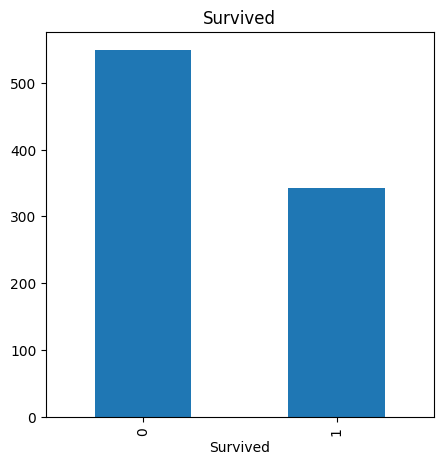

In [76]:
data["Survived"].value_counts().plot(kind="bar",figsize=(5,5))
plt.title("Survived")

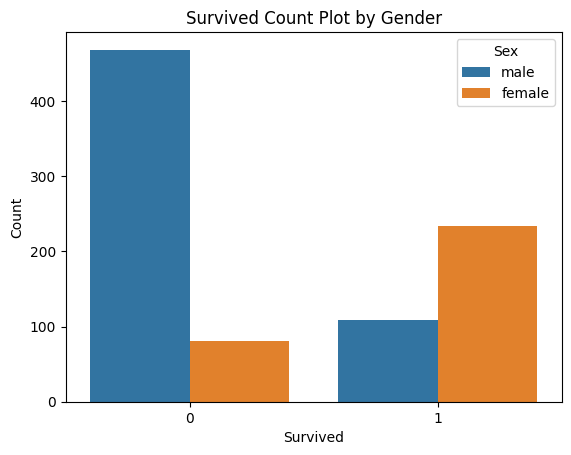

In [77]:
sns.countplot(x='Survived', hue='Sex', data=data)
plt.title("Survived Count Plot by Gender")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

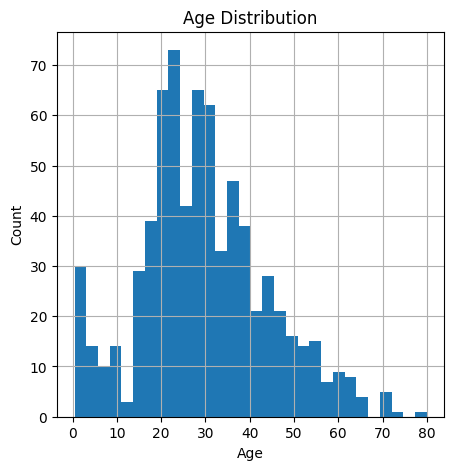

In [78]:
data["Age"].hist(bins=30,figsize=(5,5))
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [79]:
print("Misssing Values:",data.isnull().sum())

Misssing Values: PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [80]:
data["Age"] = data["Age"].fillna(data["Age"].median())

In [81]:
data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])

In [82]:
data.drop("Cabin",axis=1,inplace=True)

In [83]:
print("\nMissing Values After fix:\n")

print("Missing Values:",data.isnull().sum())


Missing Values After fix:

Missing Values: PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [84]:
print("Duplicate Values:",data.duplicated().sum())

Duplicate Values: 0


In [85]:
data.drop(["PassengerId","Name","Ticket"],axis=1,inplace=True)

In [86]:
data = pd.get_dummies(data, columns=["Sex", "Embarked"], drop_first=True)

In [87]:
print(data.dtypes)

Survived        int64
Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Sex_male         bool
Embarked_Q       bool
Embarked_S       bool
dtype: object


In [88]:
bool_cols = ["Sex_male","Embarked_Q","Embarked_S"]

data[bool_cols] = data[bool_cols].astype(int)

In [89]:
data.dtypes

,0
Survived,int64
Pclass,int64
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Sex_male,int64
Embarked_Q,int64
Embarked_S,int64


## ✂️ Step 4 — Data Preprocessing & Splitting

In [90]:
X=data.drop("Survived",axis=1)
y=data["Survived"]

In [91]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [92]:
Scaler=StandardScaler()
X_train=Scaler.fit_transform(X_train)
X_test=Scaler.transform(X_test)

## 🤖 Step 5 — Model Training

In [93]:
model=LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [94]:
# Compare Multiple Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree":       DecisionTreeClassifier(),
    "Random Forest":       RandomForestClassifier(),
}

print("Model Comparison:")
print("-"*40)
for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print(f"{name:25}: {acc:.4f}")

Model Comparison:
----------------------------------------
Logistic Regression      : 0.8101
Decision Tree            : 0.7877
Random Forest            : 0.8101


In [95]:
# Cross Validation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    LogisticRegression(),
    X_train, y_train, cv=5)

print("CV Scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean().round(4))
print("Std Dev:", cv_scores.std().round(4))

CV Scores: [0.82517483 0.8041958  0.78873239 0.73943662 0.78873239]
Mean CV Score: 0.7893
Std Dev: 0.0283


In [96]:
y_pred=model.predict(X_test)

In [97]:
print("Accuracy Score:",accuracy_score(y_test,y_pred))

Accuracy Score: 0.8100558659217877


## ⚙️ Step 6 — Hyperparameter Tuning

In [98]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 0.5, 1, 5, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']  # liblinear supports both l1 and l2
}

grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

# Use best model to predict
y_pred = grid.best_estimator_.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Best Parameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Accuracy: 0.7934797596769428
Test Accuracy: 0.8044692737430168


## 📊 Step 7 — Evaluation

In [99]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[89 16]
 [19 55]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.85      0.84       105
           1       0.77      0.74      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179

